# IMPORT

In [1]:
import torch
import matplotlib.pyplot as plt
import numpy as np
import random
import math
import time
from memory_profiler import memory_usage

c:\Users\ARRF\Desktop\Maruthi\myenv\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


# SEED

In [2]:
# Set a seed value
seed_value = 42
random.seed(seed_value)
np.random.seed(seed_value)
torch.manual_seed(seed_value)

# CUDA

In [3]:
if torch.cuda.is_available():
    torch.cuda.manual_seed(seed_value)
    torch.cuda.manual_seed_all(seed_value)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
print(torch.cuda.is_available())
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Using device:', device)
print()

True
Using device: cuda



# READ TSP FILE

In [4]:
def read_tsp_file(filename):
    with open(filename, 'r') as f:
        lines = f.readlines()
    
    city_coords = []
    for line in lines:
        if line.startswith('EOF'):
            break
        if line[0].isdigit():
            _, x, y = line.strip().split()
            city_coords.append((float(x), float(y)))
    
    n = len(city_coords)
    distance_matrix = torch.zeros((n, n), device=device)
    for i in range(n):
        for j in range(n):
            if i != j:
                distance = math.sqrt((city_coords[i][0] - city_coords[j][0])**2 + (city_coords[i][1] - city_coords[j][1])**2)
                distance_matrix[i][j] = distance
    
    return distance_matrix, city_coords

# PLOT PATH

In [5]:
def plot_tsp_path(city_coords, path):
    x = [coord[0] for coord in city_coords]
    y = [coord[1] for coord in city_coords]
    
    plt.scatter(x, y, c='blue')
    for i in range(len(path) - 1):
        plt.plot([x[path[i]], x[path[i+1]]], [y[path[i]], y[path[i+1]]], c='red')
    plt.plot([x[path[-1]], x[path[0]]], [y[path[-1]], y[path[0]]], c='red')
    
    plt.xlabel('X')
    plt.ylabel('Y')
    plt.title('TSP path with Hill-climbing')
    plt.show()

# TOTAL DISTANCE

In [6]:
def total_distance(path, distance_matrix):
    distance = 0
    for i in range(len(path) - 1):
        distance += distance_matrix[path[i]][path[i+1]]
    distance += distance_matrix[path[-1]][path[0]]
    return distance

# HILL CLIMBING

In [7]:
def hill_climbing(distance_matrix, max_iterations):
    n = distance_matrix.shape[0]
    current_path = torch.randperm(n, device=device)
    current_cost = total_distance(current_path, distance_matrix)
    best_path = current_path
    best_cost = current_cost

    for iteration in range(max_iterations):
        i, j = torch.randint(0, n, (2,), device=device)
        new_path = current_path.clone()
        new_path[i], new_path[j] = new_path[j], new_path[i]
        new_cost = total_distance(new_path, distance_matrix)

        if new_cost < current_cost:
            current_path = new_path
            current_cost = new_cost

            if new_cost < best_cost:
                best_path = new_path
                best_cost = new_cost

    return best_cost.item(), best_path.cpu().tolist()

# DS1

Optimal Cost: 1007.9545288085938
Optimal Path: [20, 89, 89, 55, 55, 55, 55, 20, 20, 20, 20, 20, 20, 0, 0, 55, 55, 55, 55, 55, 55, 55, 55, 55, 124, 124, 20, 20, 20, 20, 20, 20, 20, 20, 55, 55, 64, 64, 28, 28, 72, 72, 3, 3, 3, 20, 20, 20, 20, 20, 20, 20, 20, 55, 55, 55, 117, 117, 117, 45, 45, 55, 55, 55, 20, 20, 20, 20, 20, 55, 55, 47, 47, 55, 55, 55, 47, 47, 47, 47, 55, 55, 55, 55, 55, 64, 64, 64, 75, 75, 55, 55, 28, 28, 28, 98, 98, 63, 63, 44, 44, 44, 89, 89, 47, 47, 47, 47, 20, 20, 20, 20, 20, 104, 104, 20, 20, 20, 20, 20, 101, 101, 101, 101, 63, 63, 63, 20, 20, 20, 20]
Execution Time: 4377.406166791916 seconds
Memory Usage: 1448.0546875 MiB


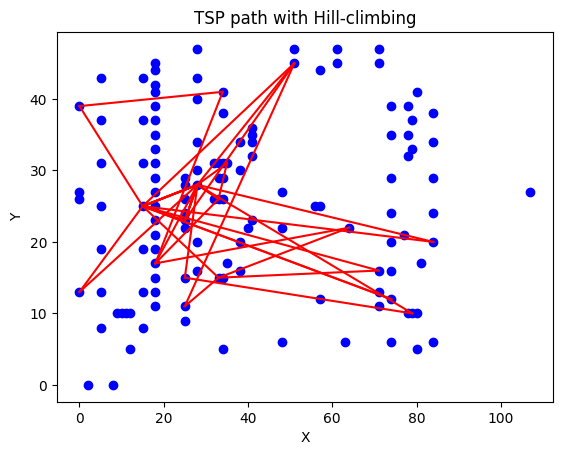

In [11]:
filename = 'C://Users//ARRF//Desktop//rebeka//mid_term_project//data//DS1//DS1.tsp'
distance_matrix, city_coords = read_tsp_file(filename)

start_time = time.time()
cost, path = hill_climbing(distance_matrix, max_iterations=100000)
end_time = time.time()

print(f"Optimal Cost: {cost}")
print(f"Optimal Path: {path}")
print(f"Execution Time: {end_time - start_time} seconds")

mem_usage = memory_usage(proc=-1, interval=1, timeout=1)
print(f"Memory Usage: {max(mem_usage)} MiB")

plot_tsp_path(city_coords, path)

# DS2

Optimal Cost: 59138.2890625
Optimal Path: [1180, 1400, 1433, 1214, 1214, 1066, 1181, 1182, 902, 819, 547, 629, 544, 739, 538, 501, 538, 1208, 1259, 1085, 1048, 987, 991, 884, 784, 1136, 1033, 866, 525, 272, 662, 743, 518, 325, 547, 758, 674, 601, 553, 585, 676, 394, 576, 507, 647, 731, 585, 725, 794, 794, 718, 713, 713, 662, 1125, 1470, 1040, 1353, 1365, 1289, 1508, 594, 527, 309, 421, 784, 821, 206, 328, 386, 688, 662, 749, 560, 458, 521, 510, 547, 41, 20, 12, 88, 422, 783, 911, 939, 857, 823, 794, 599, 496, 433, 730, 794, 394, 510, 493, 639, 552, 552, 428, 405, 670, 573, 647, 217, 124, 591, 784, 676, 786, 675, 596, 592, 428, 576, 639, 523, 509, 206, 387, 713, 784, 420, 426, 585, 881, 1050, 1266, 547, 544, 544, 571, 413, 453, 377, 1331, 1520, 966, 1073, 1107, 1069, 585, 206, 253, 748, 582, 843, 670, 544, 537, 1100, 1147, 978, 1100, 901, 972, 1494, 1205, 1182, 1151, 1191, 887, 599, 676, 670, 821, 789, 756, 217, 217, 386, 296, 695, 695, 766, 847, 717, 318, 244, 670, 1164, 959, 1243, 131

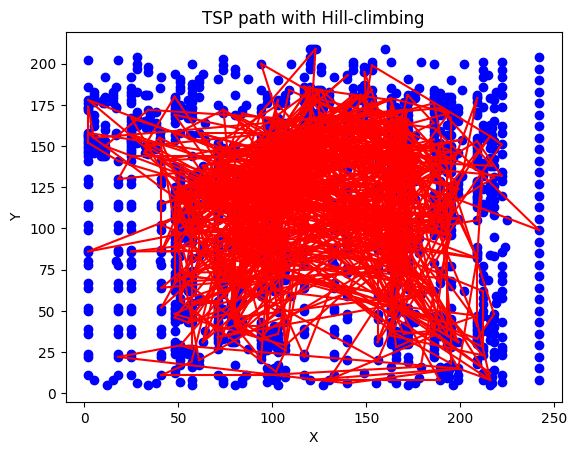

In [9]:
import time
from memory_profiler import memory_usage

filename = 'C://Users//ARRF//Desktop//rebeka//mid_term_project//data//DS2//DS2.tsp'
distance_matrix, city_coords = read_tsp_file(filename)

start_time = time.time()
cost, path = hill_climbing(distance_matrix,max_iterations=10000)
end_time = time.time()

print(f"Optimal Cost: {cost}")
print(f"Optimal Path: {path}")
print(f"Execution Time: {end_time - start_time} seconds")

mem_usage = memory_usage(proc=-1, interval=1, timeout=1)
print(f"Memory Usage: {max(mem_usage)} MiB")

plot_tsp_path(city_coords, path)

# DS3

Optimal Cost: 982934.8125
Optimal Path: [2203, 1292, 2301, 2201, 2072, 3475, 3196, 2896, 4012, 4274, 4922, 2754, 2971, 2844, 2169, 2348, 31, 309, 931, 2176, 3084, 3117, 3181, 3084, 3174, 3709, 4016, 3640, 3290, 3983, 3929, 2084, 2578, 4874, 2794, 3022, 4272, 5029, 3969, 3479, 5073, 4016, 3412, 1919, 2290, 2791, 3291, 4693, 3805, 4709, 3046, 5017, 2791, 2606, 2768, 1241, 4289, 3913, 4041, 4395, 4439, 4130, 4577, 640, 1267, 1830, 795, 1347, 1774, 2842, 3658, 3052, 1830, 1802, 717, 595, 2339, 1758, 1553, 2614, 4693, 3353, 3119, 1629, 1588, 1245, 4016, 4601, 4546, 5002, 3728, 1212, 2146, 2909, 2499, 4061, 2523, 2120, 1711, 1223, 1242, 1152, 2121, 2719, 3569, 3747, 4234, 4660, 1947, 2996, 4247, 4582, 4376, 4187, 4052, 3653, 3906, 3084, 3600, 2822, 3215, 2728, 3797, 3339, 4041, 3131, 2059, 2701, 4156, 436, 2524, 2120, 4088, 2551, 3532, 4205, 2910, 2501, 2711, 2085, 2424, 1568, 1120, 601, 2015, 1304, 575, 727, 420, 543, 676, 5049, 3611, 2074, 1558, 2636, 4394, 4536, 3917, 2508, 3228, 3709, 85

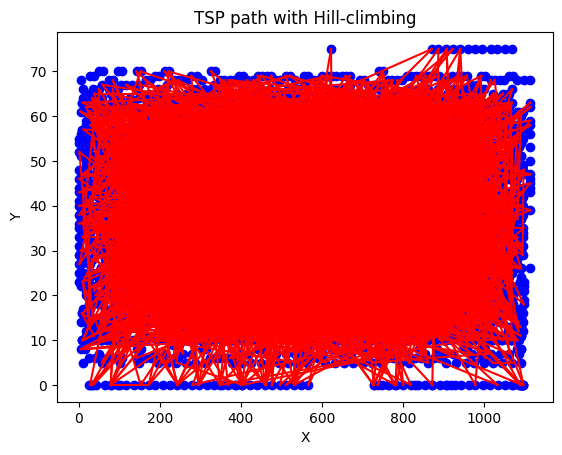

In [10]:
import time
from memory_profiler import memory_usage

filename = 'C://Users//ARRF//Desktop//rebeka//mid_term_project//data//DS3//DS3.tsp'
distance_matrix, city_coords = read_tsp_file(filename)

start_time = time.time()
cost, path = hill_climbing(distance_matrix,max_iterations=10000)
end_time = time.time()

print(f"Optimal Cost: {cost}")
print(f"Optimal Path: {path}")
print(f"Execution Time: {end_time - start_time} seconds")

mem_usage = memory_usage(proc=-1, interval=1, timeout=1)
print(f"Memory Usage: {max(mem_usage)} MiB")

plot_tsp_path(city_coords, path)